# 1- preparing the regional dataset

- Imports
  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


- Dataset filtering

In [2]:
df=pd.read_csv('../data/df_final_dataset.csv')
#isolating data for regional analysis
territory_type_col= 'Collectivités territoriales'
keyword = 'Région'
print(f"\nFiltering for rows where the '{territory_type_col}' column contains the keyword: '{keyword}'")

df_regional = df[df[territory_type_col].str.contains(keyword, na=False)].copy()
print("\nregional data isolation complete")
print(f"original dataset had {len(df)} rows(all levels)")
print(f"the new regional dataset has {len(df_regional)} rows.")

display(df_regional.head())


Filtering for rows where the 'Collectivités territoriales' column contains the keyword: 'Région'

regional data isolation complete
original dataset had 2016 rows(all levels)
the new regional dataset has 12 rows.


,Code géographique,Collectivités territoriales,Population légale_ENSEMBLE_TOTAL,Population municipale_ENSEMBLE_TOTAL,Sexe (%)_Masculin_ENSEMBLE_TOTAL,Sexe (%)_Féminin_ENSEMBLE_TOTAL,Âge quinquennal (%)_0-4 ans_ENSEMBLE_TOTAL,Âge quinquennal (%)_5-9 ans_ENSEMBLE_TOTAL,Âge quinquennal (%)_10-14 ans_ENSEMBLE_TOTAL,Âge quinquennal (%)_15-19 ans_ENSEMBLE_TOTAL,...,Mode d’évacuation des déchets ménagers (%)_Bac à ordures de la commune_RURALE,Mode d’évacuation des déchets ménagers (%)_Camion de la commune / Camion privé_RURALE,Mode d’évacuation des déchets ménagers (%)_Dans la nature_RURALE,Mode d’évacuation des déchets ménagers (%)_Autre_RURALE,Combustible de cuisson utilisé (%)_Gaz_RURALE,Combustible de cuisson utilisé (%)_Électricité_RURALE,Combustible de cuisson utilisé (%)_Charbon_RURALE,Combustible de cuisson utilisé (%)_Bois énergie_RURALE,Combustible de cuisson utilisé (%)_Autre_RURALE,Distance moyenne des logements à la route goudronnée (Km)_RURALE
0,01,Région de Tanger-Tétouan-Al Hoceima,4030222,4008655,50.8,49.2,8.2,9.6,9.4,7.9,...,11.0,2.1,81.1,5.8,94.0,0.3,1.0,4.5,0.2,2.3
203,02,Région de l'Oriental,2294665,2269378,48.9,51.1,6.8,8.9,9.5,7.8,...,11.3,11.7,72.6,4.5,88.2,0.2,0.1,11.0,0.5,2.0
372,03,Région de Fès-Meknès,4467911,4436873,49.7,50.3,7.6,9.2,9.7,8.5,...,9.2,6.3,81.8,2.7,88.2,0.3,0.2,10.9,0.5,1.9
640,04,Région de Rabat-Salé-Kénitra,5132639,5088656,49.7,50.3,7.5,8.9,9.2,7.9,...,7.6,3.3,85.4,3.7,92.4,0.3,0.9,6.0,0.3,1.0
806,05,Région de Béni Mellal-Khénifra,2525801,2510799,48.9,51.1,7.4,9.5,10.3,8.5,...,11.6,9.5,76.3,2.6,78.6,0.2,0.5,20.3,0.4,1.4


# 2- Descriptive Statistics

In [3]:
print("describing variation between regions for each indicator")

# using .T for better readability
regional_descriptive_stats = df_regional.describe().T

print(regional_descriptive_stats)

describing variation between regions for each indicator
                                                    count          mean  \
Population légale_ENSEMBLE_TOTAL                     12.0  3.069028e+06   
Population municipale_ENSEMBLE_TOTAL                 12.0  3.040883e+06   
Sexe (%)_Masculin_ENSEMBLE_TOTAL                     12.0  5.048333e+01   
Sexe (%)_Féminin_ENSEMBLE_TOTAL                      12.0  4.951667e+01   
Âge quinquennal (%)_0-4 ans_ENSEMBLE_TOTAL           12.0  7.866667e+00   
...                                                   ...           ...   
Combustible de cuisson utilisé (%)_Électricité_...   12.0  1.733333e+00   
Combustible de cuisson utilisé (%)_Charbon_RURALE    12.0  4.500000e-01   
Combustible de cuisson utilisé (%)_Bois énergie...   12.0  1.068333e+01   
Combustible de cuisson utilisé (%)_Autre_RURALE      12.0  3.833333e-01   
Distance moyenne des logements à la route goudr...   12.0  1.616667e+00   

                                           

- the statistics reveal extreme inequality in population distribution across the 12 regions. the standards deviation (std=2.27M) is exceptionally high, and the mean 3,07M is significanltly pulled up by an outlier region, as it's much larger than the median(2,77m). this indiates that one or two regions are demographic heavyweights.

- the gender balance is stable across the 12 regions, the std is extremely low, and both females and males percentages hover tightly around 50%( implying the overall gender ration is not a differentiating factor for regional developement).

- observation on cooking fuel: this indicator reveals a severe developement gap . while the median region's usage is extremly low (50%= 0,25%), the max=18,1% points to at least one highly modernized outlier region.

In [4]:
regional_descriptive_stats['CV'] = regional_descriptive_stats['std'] / (regional_descriptive_stats['mean'] + 1e-9)

# Sort by the CV to see the most unequal indicators at the top
print(" Top 10 Most Unequal Indicators Between Regions (by CV)")
print(regional_descriptive_stats.sort_values(by='CV', ascending=False).head(10))

 Top 10 Most Unequal Indicators Between Regions (by CV)
                                                    count      mean  \
Combustible de cuisson utilisé (%)_Électricité_...   12.0  1.733333   
Langues locales utilisées (non exclusives) (%)_...   12.0  4.241667   
Langues locales utilisées (non exclusives) (%)_...   12.0  4.350000   
Langues locales utilisées (non exclusives) (%)_...   12.0  4.450000   
Langues locales utilisées (non exclusives) (%)_...   12.0  6.950000   
Langues locales utilisées (non exclusives) (%)_...   12.0  6.533333   
Langues locales utilisées (non exclusives) (%)_...   12.0  3.516667   
Langues locales utilisées (non exclusives) (%)_...   12.0  3.591667   
Langues locales utilisées (non exclusives) (%)_...   12.0  3.666667   
Langues locales utilisées (non exclusives) (%)_...   12.0  3.116667   

                                                          std  min    25%  \
Combustible de cuisson utilisé (%)_Électricité_...   5.154404  0.2  0.200   
Langues 

The top 10 most variable indicators between regions are dominated by cultural and linguistic factors (Langues locales utilisées), not purely economic or demographic ones.
This reveals that the most significant relative differences between Moroccan regions are tied to the concentrated use of local languages. 

- **Visualizing Regional Rankings with Bar Charts**

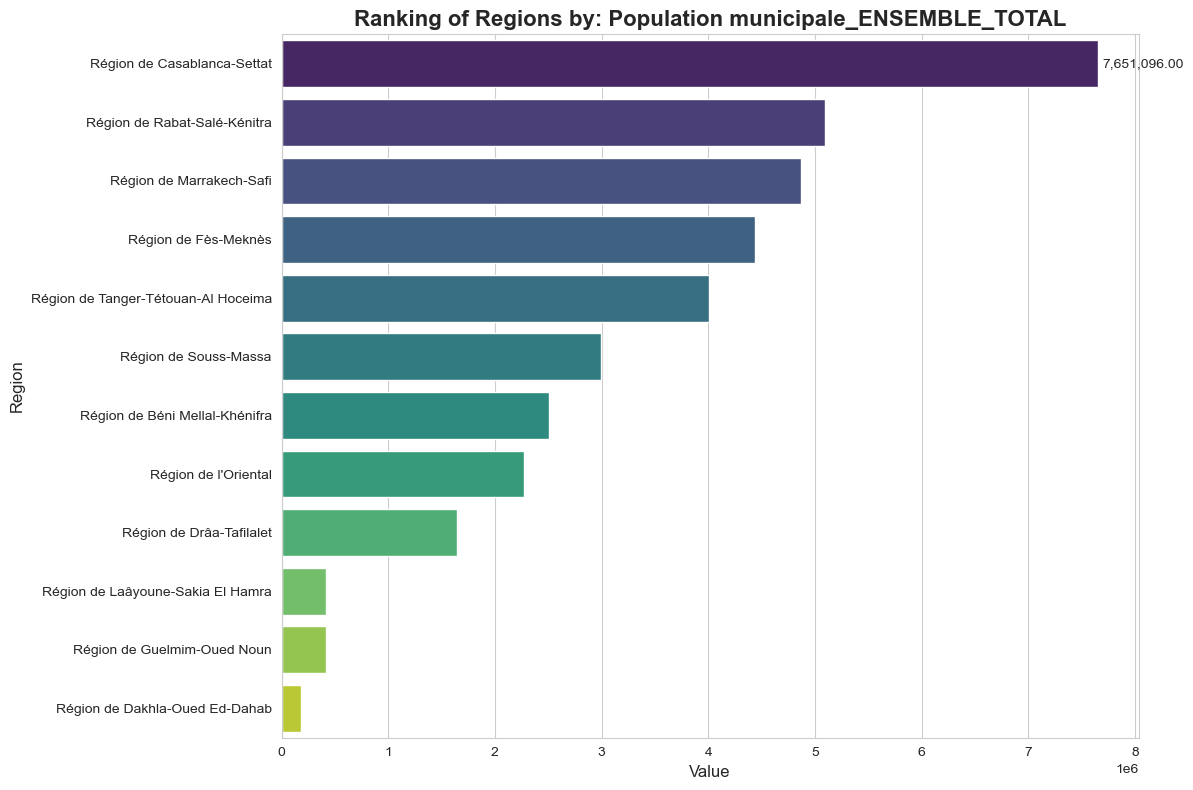

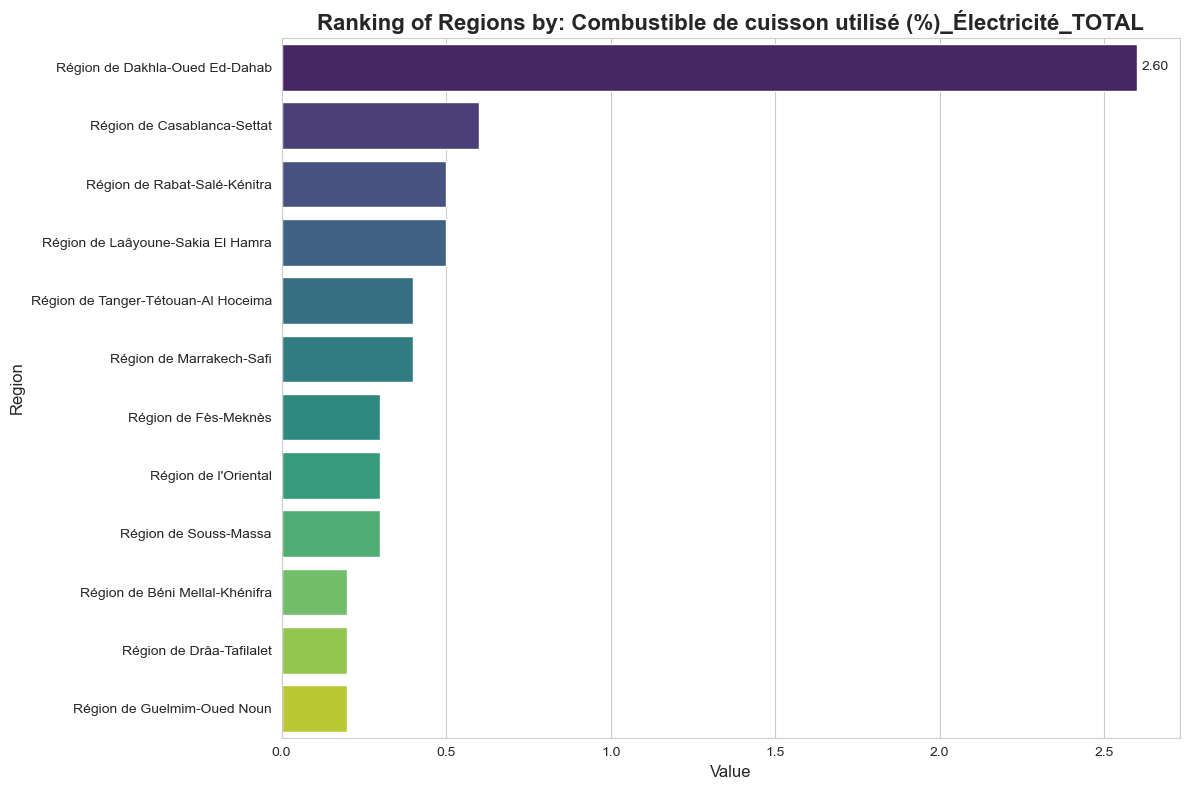

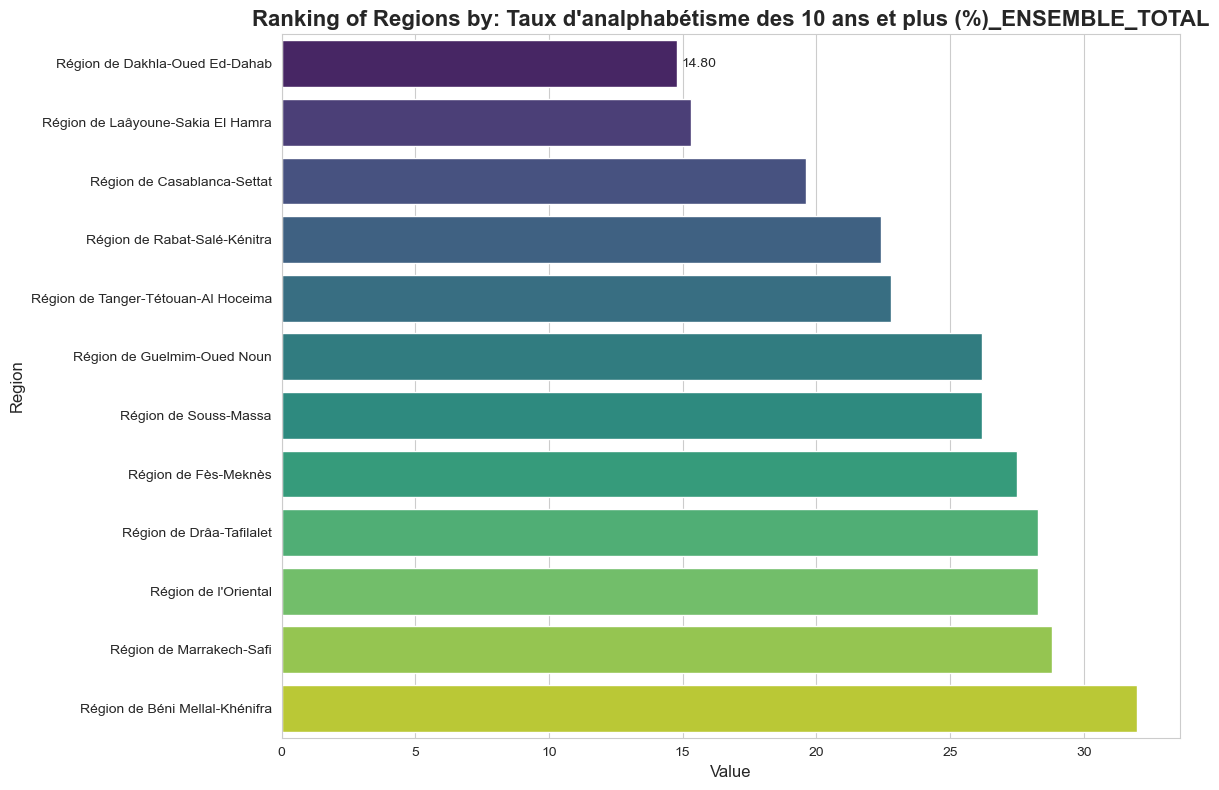

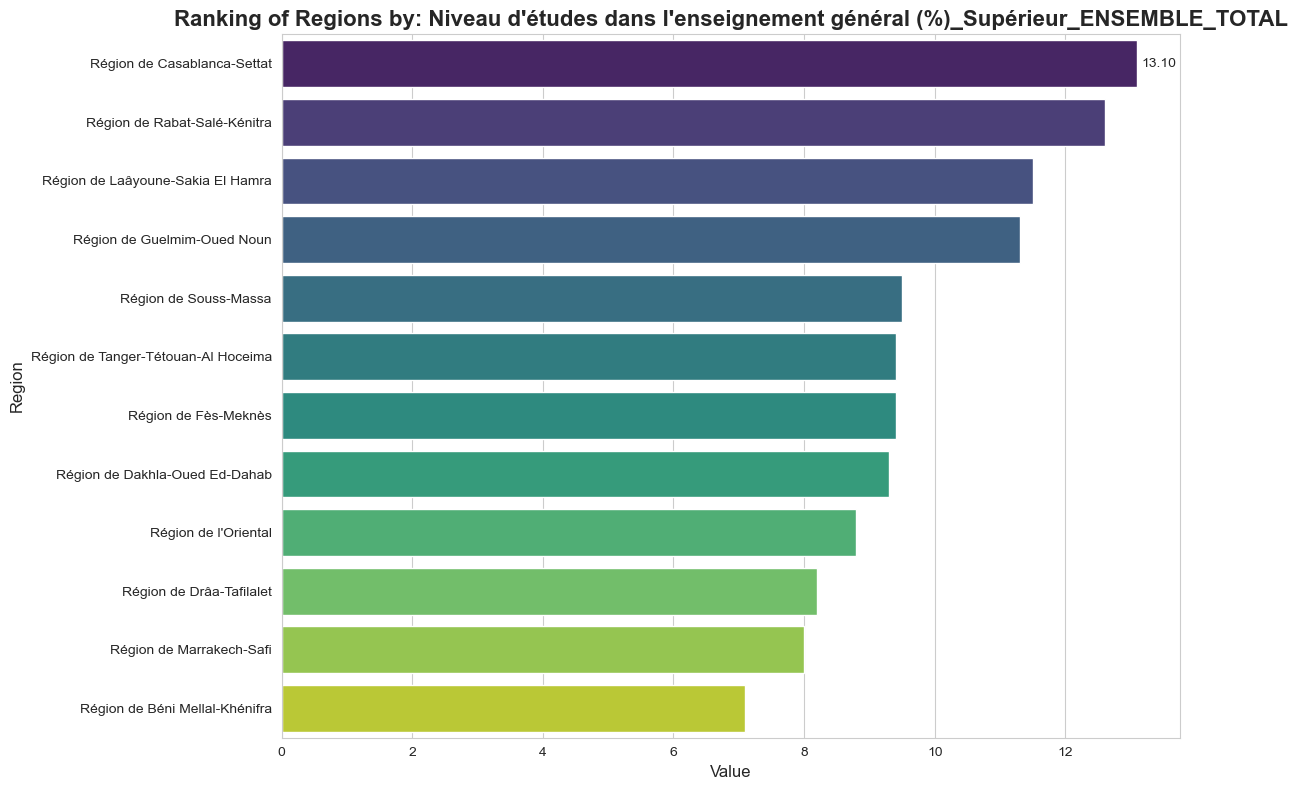

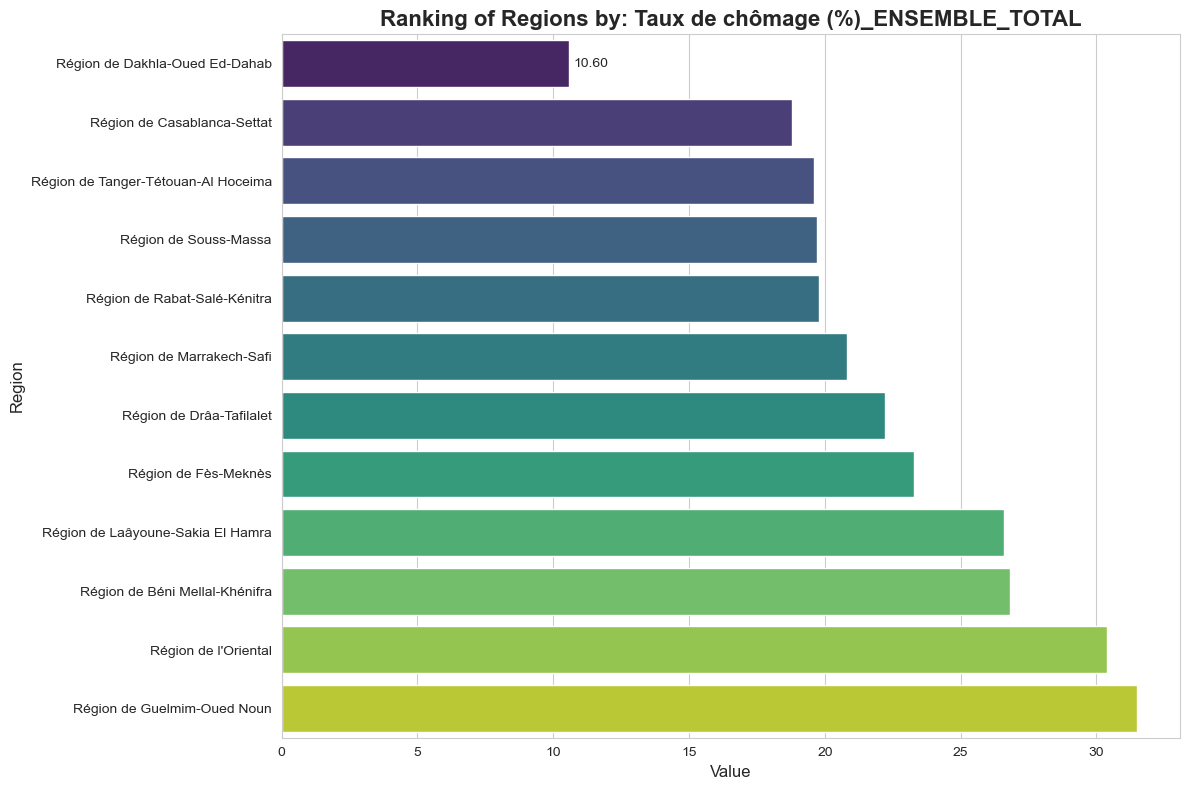

In [11]:

geo_name_col = 'Collectivités territoriales'

key_indicators = ["Population municipale_ENSEMBLE_TOTAL", 
                  "Combustible de cuisson utilisé (%)_Électricité_TOTAL",
                  "Taux d'analphabétisme des 10 ans et plus (%)_ENSEMBLE_TOTAL",
                  "Niveau d'études dans l'enseignement général (%)_Supérieur_ENSEMBLE_TOTAL",
                  "Taux de chômage (%)_ENSEMBLE_TOTAL"]

for indicator in key_indicators:
    # For some indicators, a lower value is better (like illiteracy)
    is_ascending = True if 'analphabétisme' in indicator or 'chômage' in indicator else False
    plt.figure(figsize=(12, 8))
    sorted_data = df_regional.sort_values(by=indicator, ascending=is_ascending)

    ax = sns.barplot(data=sorted_data, x=indicator, y=geo_name_col, palette='viridis',
                    hue=geo_name_col, legend=False)

    plt.title(f'Ranking of Regions by: {indicator}', fontsize=16, weight='bold')
    plt.xlabel('Value', fontsize=12)
    plt.ylabel('Region', fontsize=12)

    # This is a helpful extra: add the exact value label to the end of each bar.
    ax.bar_label(ax.containers[0], fmt='{:,.2f}', padding=3, fontsize=10)
    
    # This automatically adjusts the plot to make sure nothing is cut off.
    plt.tight_layout()
    
    # Finally, display the plot.
    plt.show()

    
    
    
    
    


